# Credit Card Fraud Detection

This notebook handles Exploratory Data Analysis (EDA), Feature Engineering, Imbalance Handling, and Model Training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & EDA

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

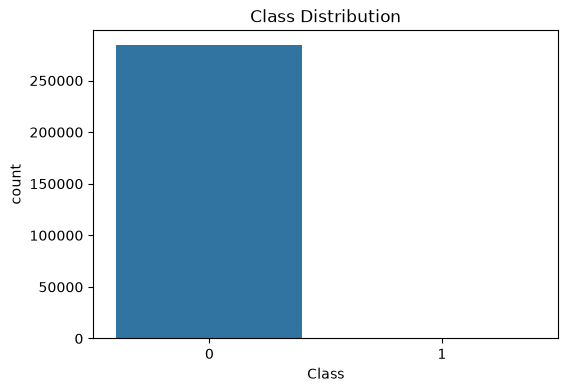

In [2]:
# Load dataset
df = pd.read_csv('../data/creditcard.csv')
print(df.head())
print(f"Dataset shape: {df.shape}")

# Class imbalance
counts = df['Class'].value_counts()
print(counts)
print(f"Fraud Percentage: {counts[1] / len(df) * 100:.3f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

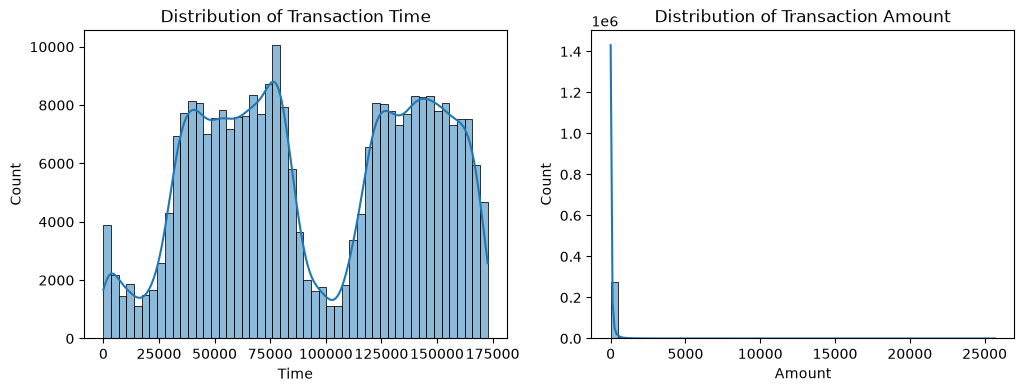

In [3]:
# Time and Amount distribution
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Time'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of Transaction Time')
sns.histplot(df['Amount'], bins=50, ax=ax[1], kde=True)
ax[1].set_title('Distribution of Transaction Amount')
plt.show()

## 2. Feature Engineering & Scaling

In [4]:
# Scale Time and Amount
scaler_time = StandardScaler()
scaler_amount = StandardScaler()

df['Time_scaled'] = scaler_time.fit_transform(df['Time'].values.reshape(-1,1))
df['Amount_scaled'] = scaler_amount.fit_transform(df['Amount'].values.reshape(-1,1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder columns
scaled_amount = df['Amount_scaled']
scaled_time = df['Time_scaled']
df.drop(['Amount_scaled', 'Time_scaled'], axis=1, inplace=True)
df.insert(0, 'Amount_scaled', scaled_amount)
df.insert(1, 'Time_scaled', scaled_time)

df.head()

,Amount_scaled,Time_scaled,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 3. Train-Test Split and Imbalance Handling

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split to maintain fraud ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}, Fraud cases: {sum(y_train)}")
print(f"Testing set: {X_test.shape}, Fraud cases: {sum(y_test)}")

# Apply SMOTE to training data ONLY
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"SMOTE Training set: {X_train_sm.shape}, Fraud cases: {sum(y_train_sm)}")

Training set: (227845, 30), Fraud cases: 394
Testing set: (56962, 30), Fraud cases: 98


SMOTE Training set: (454902, 30), Fraud cases: 227451


## 4. Modeling & Evaluation

In [6]:
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))
    
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)
    print(f"PR-AUC: {pr_auc:.4f}\n")
    return pr_auc

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
evaluate_model(lr, X_test, y_test, "Logistic Regression")

# 2. Random Forest (with class weight instead of SMOTE for comparison)
rf = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train) # Training on original imbalanced data with class weights
evaluate_model(rf, X_test, y_test, "Random Forest")

# 3. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42)
xgb.fit(X_train, y_train)
evaluate_model(xgb, X_test, y_test, "XGBoost")


--- Logistic Regression ---
[[55406  1458]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

PR-AUC: 0.7703



--- Random Forest ---
[[56859     5]
 [   20    78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8639



--- XGBoost ---
[[56854    10]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8726



0.8725848329377506

## 5. Save the Best Model

In [7]:
# We'll save XGBoost as it typically performs best for extreme imbalance
joblib.dump(xgb, '../models/xgboost_fraud_model.pkl')
joblib.dump(scaler_amount, '../models/scaler_amount.pkl')
joblib.dump(scaler_time, '../models/scaler_time.pkl')
print("Model and scalers saved to ../models/")

Model and scalers saved to ../models/
